In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [2]:
random_root = Path('/home/ddon0001/PhD/experiments/scaled/pre-thesis/sparse_sampling/edge_precision_random')
traj_root = Path('/home/ddon0001/PhD/experiments/scaled/pre-thesis/sparse_sampling/edge_precision_trajectory')

def load_method(root, method_name):
    dfs = []
    for f in sorted(root.glob('*.csv')):
        df = pd.read_csv(f)
        df['method'] = method_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

random_df = load_method(random_root, 'random')
traj_df = load_method(traj_root, 'trajectory')
df = pd.concat([random_df, traj_df], ignore_index=True)
print(df['ds_name'].nunique(), 'datasets,', df['method'].unique(), 'methods')
df.head()

32 datasets, ['random' 'trajectory'] methods


,ds_name,run_id,sample_id,edge_src,edge_tgt,is_tp,prec_estimate,std_error,method
0,BF-C2DL-HSC_01,0,0,8303,8315,True,1.0,0.0,random
1,BF-C2DL-HSC_01,0,1,4778,4786,True,1.0,0.0,random
2,BF-C2DL-HSC_01,0,2,1375,1379,True,1.0,0.0,random
3,BF-C2DL-HSC_01,0,3,5617,5625,True,1.0,0.0,random
4,BF-C2DL-HSC_01,0,4,1572,1576,True,1.0,0.0,random


In [3]:
# load n edges and true precision for each dataset
true_prec_root = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_no_merge_cap'
records = []
for ds_name in random_df.ds_name.unique():
    metrics_path = f'{true_prec_root}/{ds_name}/matched_solution.zarr/traccuracy-results.json'
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
    n_edges = metrics['Total Pred Edges']
    true_prec = metrics['Edge Precision']
    records.append({
        'ds_name': ds_name,
        'n_edges': n_edges,
        'true_precision': true_prec
    })
ds_info = pd.DataFrame(records)

In [4]:
df = df.merge(ds_info[['ds_name', 'n_edges']], on='ds_name')
df['frac_sampled'] = (df['sample_id'] + 1) / df['n_edges']

# aggregate across 30 runs: mean estimate, empirical SD across runs, mean theoretical SE
stats = (
    df.groupby(['ds_name', 'method', 'sample_id'])
    .agg(
        frac_sampled=('frac_sampled', 'first'),
        # over the 30 different runs
        mean_prec=('prec_estimate', 'mean'),
        # worked out over our 30 runs
        empirical_se=('prec_estimate', 'std'),
        # worked out using the finite population correction as we sample 
        # if this is close to the empirical SE, it means we can use this
        # estimate as we annotate
        mean_theoretical_se=('std_error', 'mean'),
    )
    .reset_index()
)

stats = stats.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')
stats = stats[stats['true_precision'] < 1.0]
ds_info = ds_info[ds_info['true_precision'] < 1.0]
stats.head()

,ds_name,method,sample_id,frac_sampled,mean_prec,empirical_se,mean_theoretical_se,true_precision
0,BF-C2DL-HSC_01,random,0,0.000115,1.0,0.0,0.0,0.998962
1,BF-C2DL-HSC_01,random,1,0.000231,1.0,0.0,0.0,0.998962
2,BF-C2DL-HSC_01,random,2,0.000346,1.0,0.0,0.0,0.998962
3,BF-C2DL-HSC_01,random,3,0.000461,1.0,0.0,0.0,0.998962
4,BF-C2DL-HSC_01,random,4,0.000577,1.0,0.0,0.0,0.998962


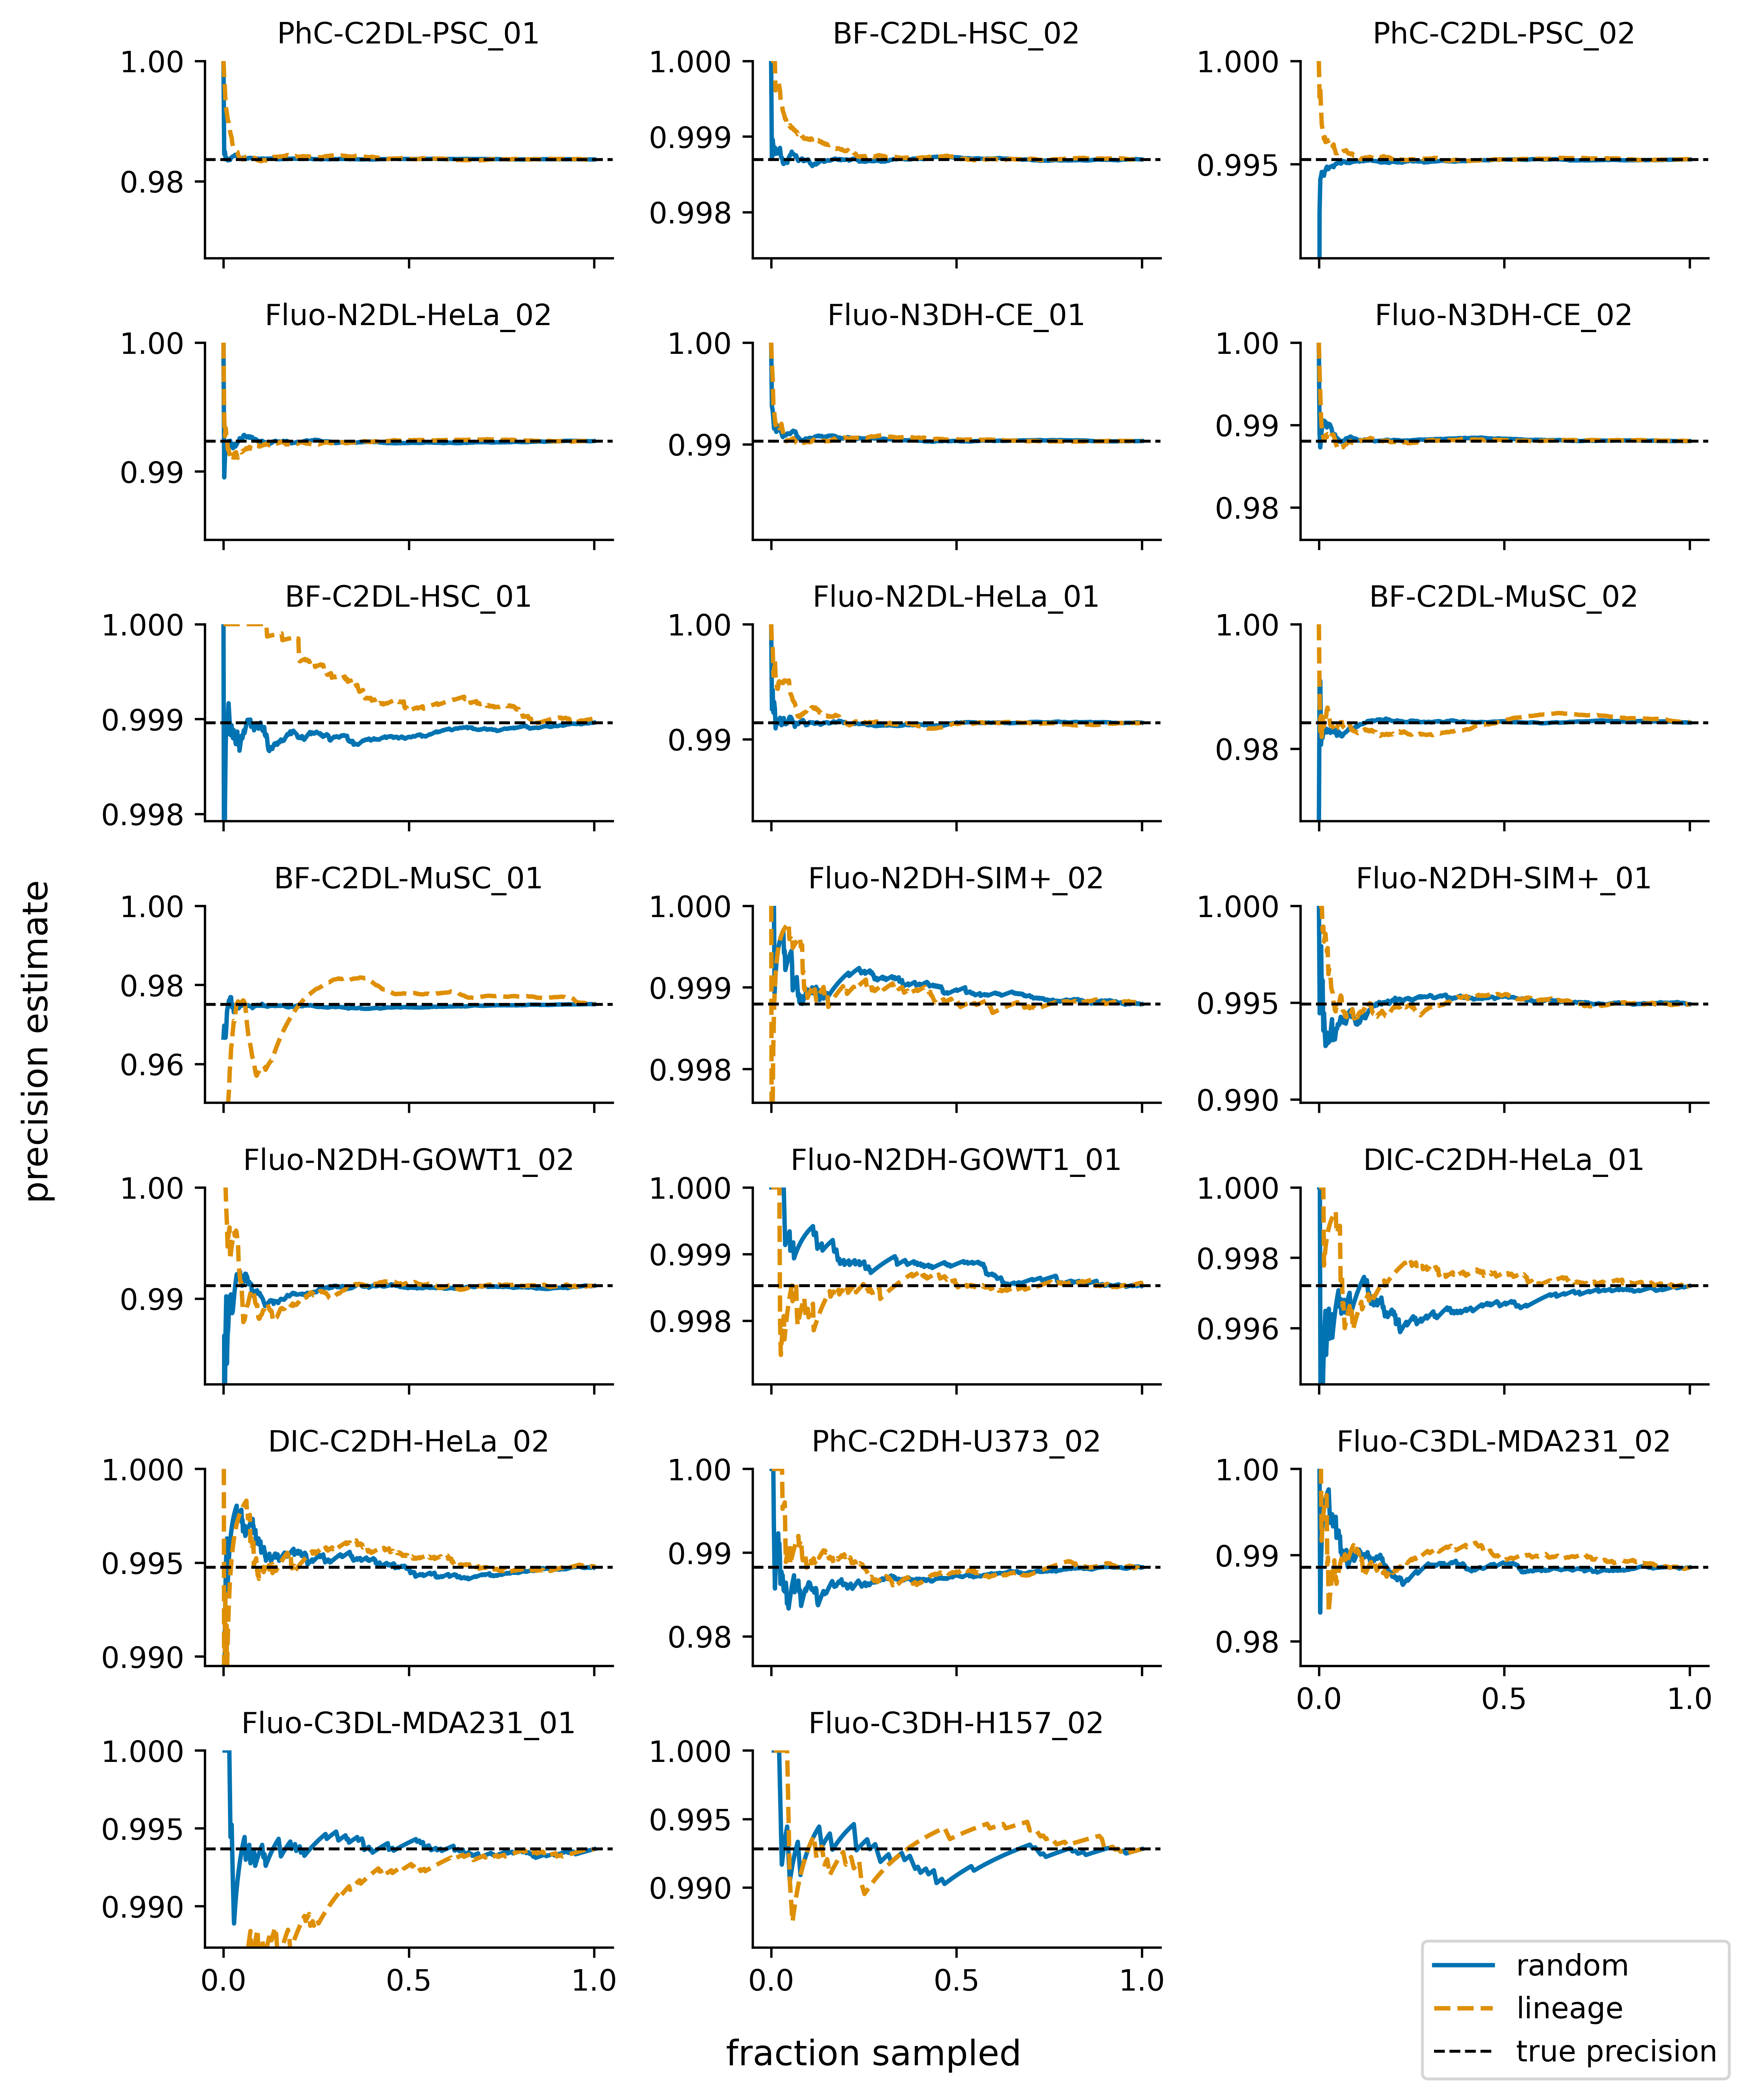

In [8]:
import seaborn as sns

colors = {'random': sns.color_palette("colorblind")[0], 'trajectory': sns.color_palette("colorblind")[1]}
linestyles = {'random': '-', 'trajectory': '--'}
col_order = ds_info.sort_values(by='n_edges', ascending=False)['ds_name'].tolist()

def plot_convergence(data, color, **kwargs):
    stride = max(1, len(data) // 500)
    data = data.iloc[::stride]
    method = data['method'].iloc[0]
    plt.plot(data['frac_sampled'], data['mean_prec'],
             color=color, linestyle=linestyles[method])

g = sns.FacetGrid(
    stats,
    col='ds_name',
    col_order=col_order,
    col_wrap=3,
    hue='method',
    palette=colors,
    height=2.5,
    aspect=1.1,
    sharey=False
)
g.figure.set_size_inches(8.27, 10)
g.figure.set_dpi(600)
g.map_dataframe(plot_convergence)
g.set_titles(col_template='{col_name}', size=10)

for ax, ds_name in zip(g.axes.flatten(), col_order):
    true_p = ds_info.loc[ds_info['ds_name'] == ds_name, 'true_precision'].values[0]
    ax.axhline(true_p, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(true_p - (1 - true_p), 1)
    ax.tick_params(labelsize=10)

g.figure.supxlabel('fraction sampled', fontsize=12, y=0.01)
g.figure.supylabel('precision estimate', fontsize=12, x=0.01)

legend_handles = [
    plt.Line2D([0], [0], color=colors['random'], linewidth=1.5, linestyle=linestyles['random'], label='random'),
    
    plt.Line2D([0], [0], color=colors['trajectory'], linewidth=1.5, linestyle=linestyles['trajectory'], label='lineage'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='true precision'),
]
g.figure.legend(handles=legend_handles, loc='lower right', fontsize=10, bbox_to_anchor=(1.0, 0.0))

plt.tight_layout()
plt.show()

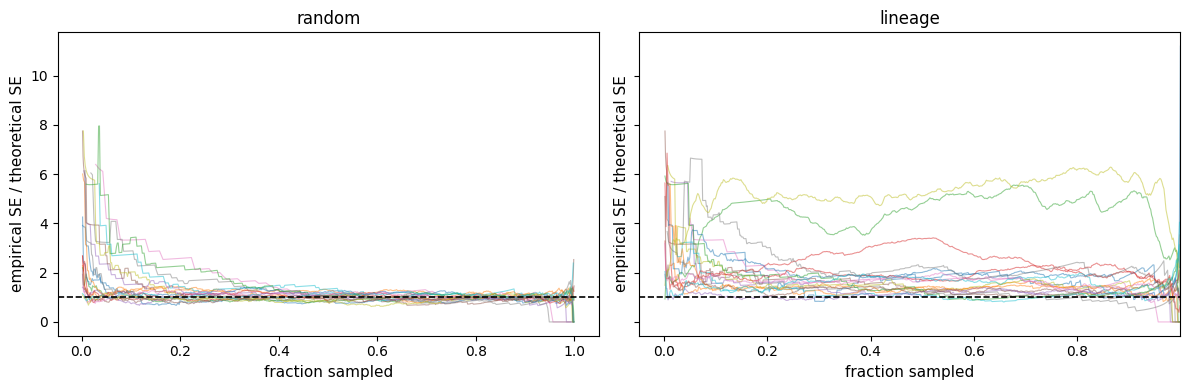

In [13]:
ratio_stats = stats.copy()
# avoid division by zero at sample_id=0 where both SEs are 0
ratio_stats['se_ratio'] = ratio_stats['empirical_se'] / ratio_stats['mean_theoretical_se'].replace(0, float('nan'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, method in zip(axes, ['random', 'trajectory']):
    sub = ratio_stats[ratio_stats['method'] == method]
    for ds_name, group in sub.groupby('ds_name'):
        stride = max(1, len(group) // 500)
        group = group.iloc[::stride]
        ax.plot(group['frac_sampled'], group['se_ratio'], linewidth=0.8, alpha=0.5)
    ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(method if method != 'trajectory' else 'lineage', fontsize=12)
    ax.set_xlabel('fraction sampled', fontsize=11)
    ax.set_ylabel('empirical SE / theoretical SE', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)
    if method == 'trajectory':
        ax.set_xlim(right=0.999)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import beta as beta_dist

PRIORS = {
    'Bayesian Beta(1,1)': (1, 1),
    'Bayesian Beta(9,1)': (9, 1),
}
CI_LEVEL = 0.95
N_CHECKPOINTS = 100
N_BOOT = 500
MIN_N_BOOT = 30
z = 1.96

true_prec_lookup = ds_info.set_index('ds_name')['true_precision']
n_edges_lookup   = ds_info.set_index('ds_name')['n_edges']

cov_df = df[df['ds_name'].isin(stats['ds_name'].unique())].copy()
cov_df = cov_df.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')
cov_df['n_sampled'] = cov_df['sample_id'] + 1
cov_df['k_fp'] = (cov_df['n_sampled'] * (1 - cov_df['prec_estimate'])).round().astype(int).clip(lower=0)

# filter to checkpoints via merge (faster than apply)
checkpoint_rows = []
for ds_name in cov_df['ds_name'].unique():
    n = int(n_edges_lookup[ds_name])
    ids = np.linspace(0, n - 1, N_CHECKPOINTS + 1, dtype=int)[1:]
    checkpoint_rows.append(pd.DataFrame({'ds_name': ds_name, 'sample_id': ids}))
checkpoints = pd.concat(checkpoint_rows, ignore_index=True)
cov_df = cov_df.merge(checkpoints, on=['ds_name', 'sample_id'])

# merge in empirical SE from stats
cov_df = cov_df.merge(
    stats[['ds_name', 'method', 'sample_id', 'empirical_se']],
    on=['ds_name', 'method', 'sample_id'], how='left'
)

coverage_records = []
rng = np.random.default_rng(42)

for (ds_name, method, sample_id), grp in cov_df.groupby(['ds_name', 'method', 'sample_id']):
    true_prec = grp['true_precision'].iloc[0]
    frac = grp['frac_sampled'].iloc[0]
    n = int(grp['n_sampled'].iloc[0])
    k_fp = grp['k_fp'].values
    prec_est = grp['prec_estimate'].values
    se = grp['std_error'].values

    rec = {
        'ds_name': ds_name, 'method': method,
        'sample_id': sample_id, 'frac_sampled': frac,
    }

    # theoretical SE
    rec['Theoretical SE'] = np.mean(
        (prec_est - z * se <= true_prec) & (true_prec <= prec_est + z * se)
    )

    # empirical SE (SD across 30 runs, same for all runs at this checkpoint)
    emp_se = grp['empirical_se'].iloc[0]
    if pd.notna(emp_se) and emp_se > 0:
        rec['Empirical SE'] = np.mean(
            (prec_est - z * emp_se <= true_prec) & (true_prec <= prec_est + z * emp_se)
        )
    else:
        rec['Empirical SE'] = float('nan')

    # Bayesian Beta posteriors — vectorised over 30 runs
    for prior_name, (a0, b0) in PRIORS.items():
        a_post = (n - k_fp) + a0
        b_post = k_fp + b0
        lo = beta_dist.ppf((1 - CI_LEVEL) / 2, a_post, b_post)
        hi = beta_dist.ppf(1 - (1 - CI_LEVEL) / 2, a_post, b_post)
        rec[prior_name] = np.mean((lo <= true_prec) & (true_prec <= hi))

    # bootstrap — vectorised over runs and boot samples
    if n >= MIN_N_BOOT:
        p_hat = k_fp / n  # FP rate per run, shape (30,)
        boot_fp = rng.binomial(n, p_hat, size=(N_BOOT, len(k_fp)))  # (N_BOOT, 30)
        boot_prec = (n - boot_fp) / n
        lo = np.percentile(boot_prec, (1 - CI_LEVEL) / 2 * 100, axis=0)
        hi = np.percentile(boot_prec, (1 - (1 - CI_LEVEL) / 2) * 100, axis=0)
        rec['Bootstrap'] = np.mean((lo <= true_prec) & (true_prec <= hi))
    else:
        rec['Bootstrap'] = float('nan')

    coverage_records.append(rec)

cov_summary = pd.DataFrame(coverage_records)

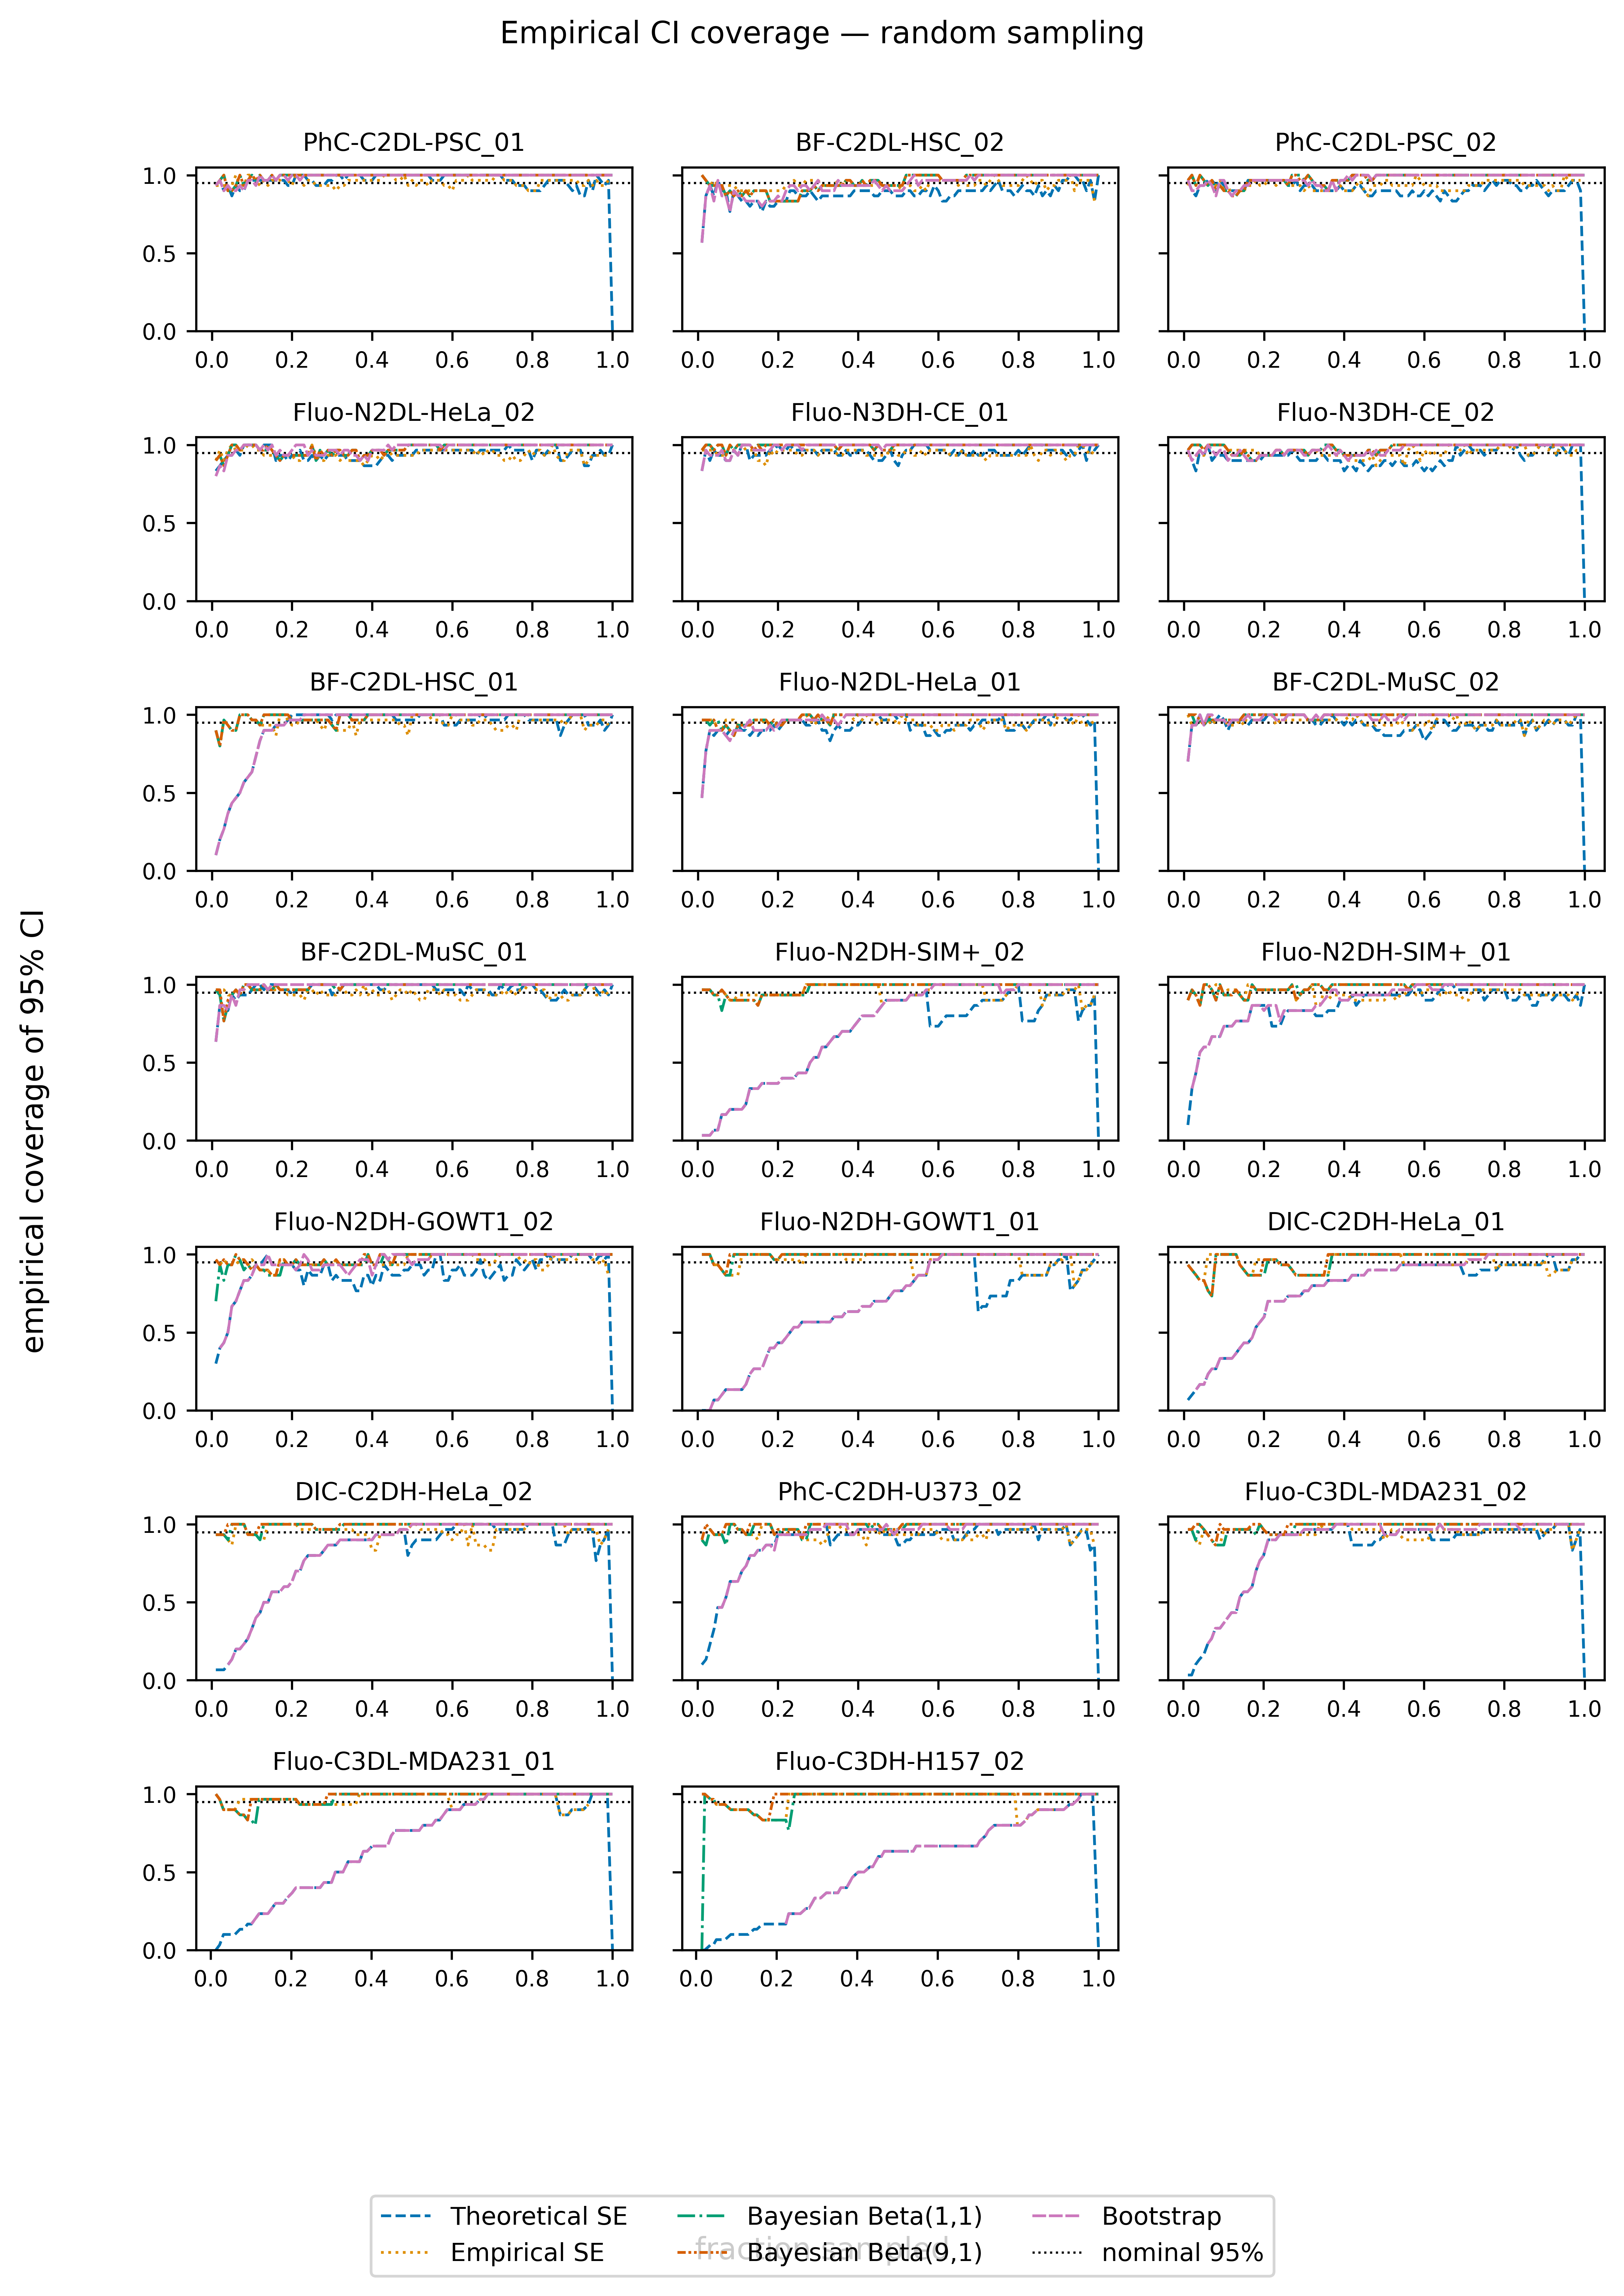

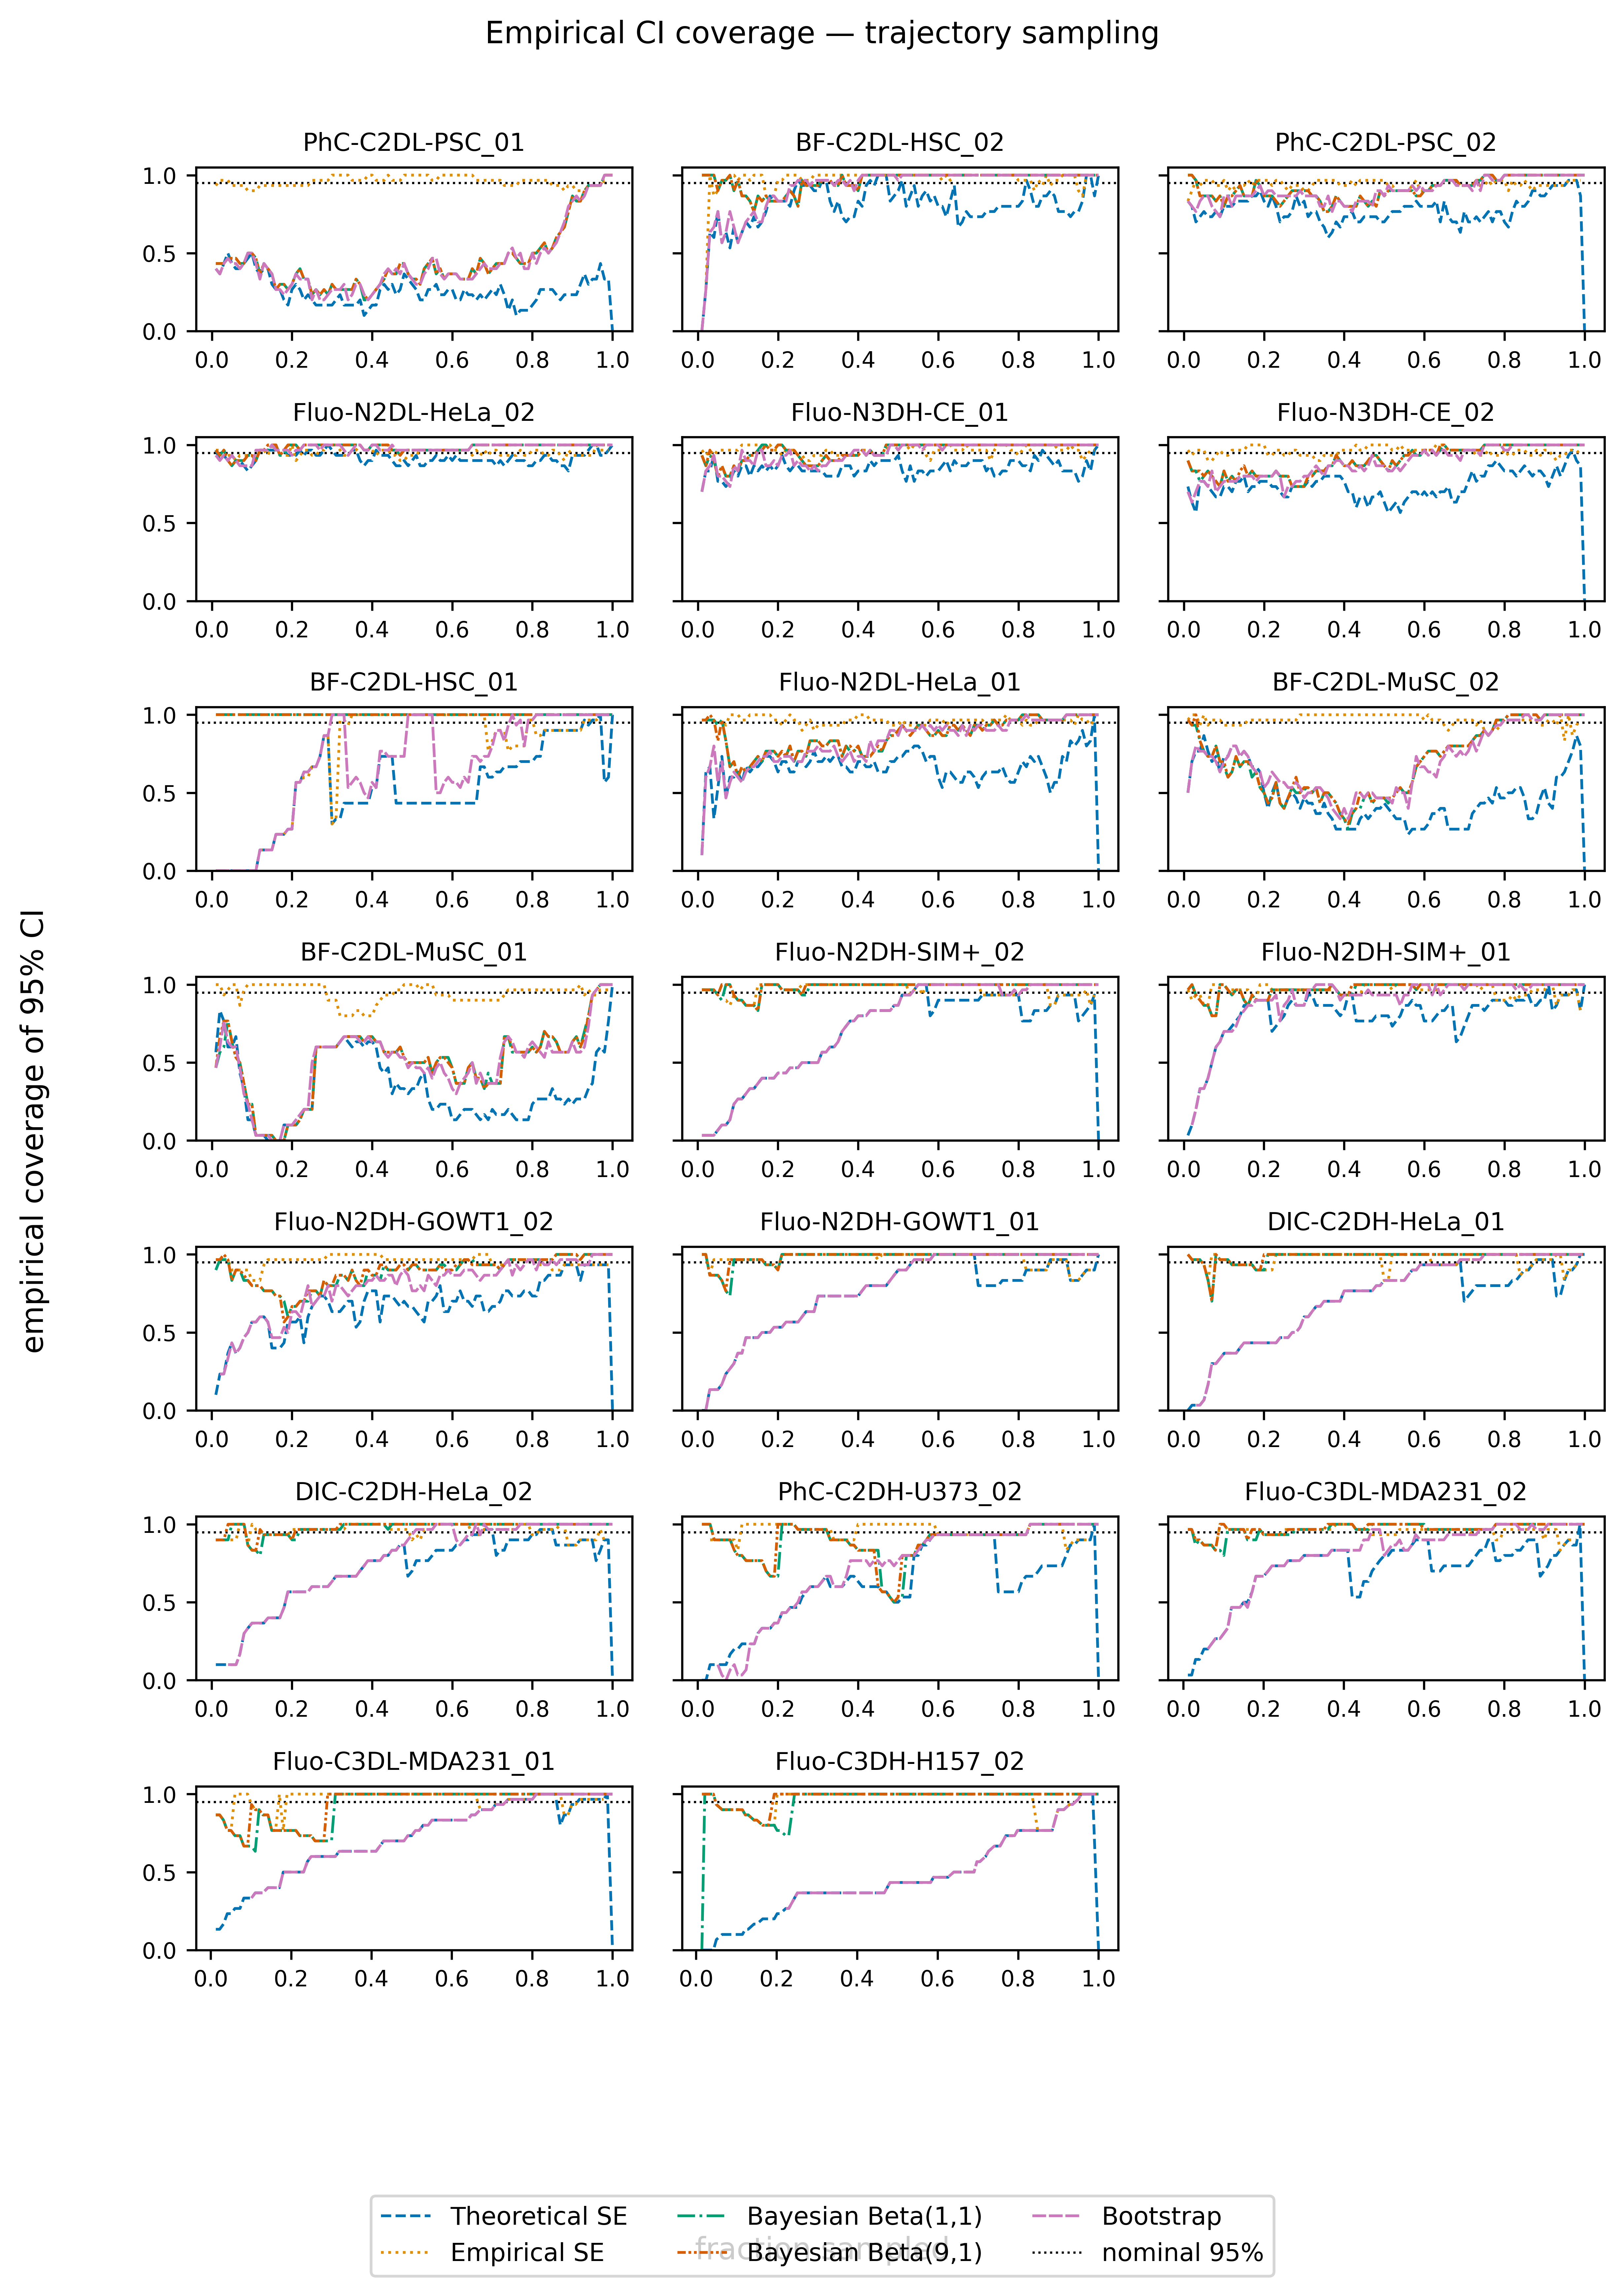

In [ ]:
coverage_cols = ['Theoretical SE', 'Empirical SE', 'Bayesian Beta(1,1)', 'Bayesian Beta(9,1)', 'Bootstrap']
palette = sns.color_palette('colorblind', len(coverage_cols))
linestyles = ['--', ':', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (5, 1))]

style_map = {
    col: {'color': palette[i], 'linestyle': linestyles[i], 'linewidth': 1}
    for i, col in enumerate(coverage_cols)
}

ncols = 3
n_ds = len(col_order)
nrows = int(np.ceil(n_ds / ncols))

for method in ['random', 'trajectory']:
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.27, 11.69),
                             sharey=True, dpi=600)
    axes = axes.flatten()

    for col_i, ds_name in enumerate(col_order):
        ax = axes[col_i]
        ax.axhline(CI_LEVEL, color='black', linewidth=0.8, linestyle=':')

        sub = cov_summary[(cov_summary['ds_name'] == ds_name) & (cov_summary['method'] == method)]
        for col, style in style_map.items():
            ax.plot(sub['frac_sampled'], sub[col], label=col, **style)

        ax.set_title(ds_name, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.tick_params(labelsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('')

    for ax in axes[n_ds:]:
        ax.set_visible(False)

    fig.supxlabel('fraction sampled', fontsize=11, y=0.01)
    fig.supylabel(f'empirical coverage of {CI_LEVEL:.0%} CI', fontsize=11, x=0.01)

    legend_handles = [
        plt.Line2D([0], [0], label=col, **style)
        for col, style in style_map.items()
    ] + [
        plt.Line2D([0], [0], color='black', linewidth=0.8, linestyle=':', label=f'nominal {CI_LEVEL:.0%}')
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, 0.0), fontsize=9)
    fig.suptitle(f'Empirical CI coverage — {method} sampling', fontsize=11)
    plt.tight_layout(rect=[0.03, 0.09, 1, 0.97])
    plt.show()

In [5]:
# difference to true precision
THRESHOLD = 0.005

def convergence_fraction(group):
    """Smallest frac_sampled where |error| drops and stays below threshold.
    Returns conv_frac, signed error, and prec_estimate at that point."""
    signed_error = group['prec_estimate'] - group['true_precision']
    abs_error = signed_error.abs()
    group['prec_error'] = abs_error
    above = (abs_error >= THRESHOLD) | (group['prec_estimate'] == 1)
    if not above.any():
        return pd.Series({'conv_frac': group['frac_sampled'].iloc[0], 'error_at_conv': signed_error.iloc[0], 'prec_at_conv': group['prec_estimate'].iloc[0]})
    if above.all():
        return pd.Series({'conv_frac': float('nan'), 'error_at_conv': float('nan'), 'prec_at_conv': float('nan')})
    last_above_pos = len(above) - 1 - above.values[::-1].argmax()
    conv_idx = last_above_pos + 1
    return pd.Series({'conv_frac': group['frac_sampled'].iloc[conv_idx], 'error_at_conv': signed_error.iloc[conv_idx], 'prec_at_conv': group['prec_estimate'].iloc[conv_idx]})

# work on per-run data, merging in true_precision and frac_sampled
conv_df = df[df['ds_name'].isin(stats['ds_name'].unique())].copy()
conv_df = conv_df.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')

conv_per_run = (
    conv_df.groupby(['ds_name', 'method', 'run_id'])
    .apply(convergence_fraction, include_groups=False)
    .reset_index()
)

# summarise across runs
conv = (
    conv_per_run.groupby(['ds_name', 'method'])
    .agg(
        conv_frac_median=('conv_frac', 'median'),
        conv_frac_p95=('conv_frac', lambda x: x.quantile(0.95)),
        error_at_conv_median=('error_at_conv', 'median'),
        estimated_prec=('prec_at_conv', 'median'),
    )
    .reset_index()
)
conv = conv.merge(ds_info[['ds_name', 'n_edges', 'true_precision']], on='ds_name')
conv['conv_n_edges_median'] = (conv['conv_frac_median'] * conv['n_edges']).round().astype(int)
conv.sort_values('conv_frac_median')

,ds_name,method,conv_frac_median,conv_frac_p95,error_at_conv_median,estimated_prec,n_edges,true_precision,conv_n_edges_median
39,PhC-C2DL-PSC_02,trajectory,0.005165,0.017927,0.001078,0.996310,56628,0.995232,292
38,PhC-C2DL-PSC_02,random,0.005439,0.015588,-0.004941,0.990291,56628,0.995232,308
36,PhC-C2DL-PSC_01,random,0.007034,0.048667,0.002592,0.986226,70941,0.983634,499
2,BF-C2DL-HSC_02,random,0.008101,0.032677,-0.000615,0.998082,64499,0.998698,522
28,Fluo-N2DL-HeLa_02,random,0.010720,0.047500,-0.004863,0.987500,25140,0.992363,270
29,Fluo-N2DL-HeLa_02,trajectory,0.016687,0.074773,-0.004968,0.987395,25140,0.992363,419
30,Fluo-N3DH-CE_01,random,0.020090,0.048288,0.001405,0.991718,23743,0.990313,477
32,Fluo-N3DH-CE_02,random,0.022422,0.106183,-0.000475,0.987570,22166,0.988045,497
3,BF-C2DL-HSC_02,trajectory,0.027248,0.051888,0.000732,0.999430,64499,0.998698,1758
31,Fluo-N3DH-CE_01,trajectory,0.033147,0.100676,0.003447,0.993760,23743,0.990313,787


In [7]:
save_path = Path('/home/ddon0001/PhD/code/tracktour-experiments/results/random_traj_convergence.csv')
save_path.parent.mkdir(exist_ok=True)
conv.to_csv(save_path, index=False)
print(f'Saved {len(conv)} rows to {save_path}')

Saved 40 rows to /home/ddon0001/PhD/code/tracktour-experiments/results/random_traj_convergence.csv


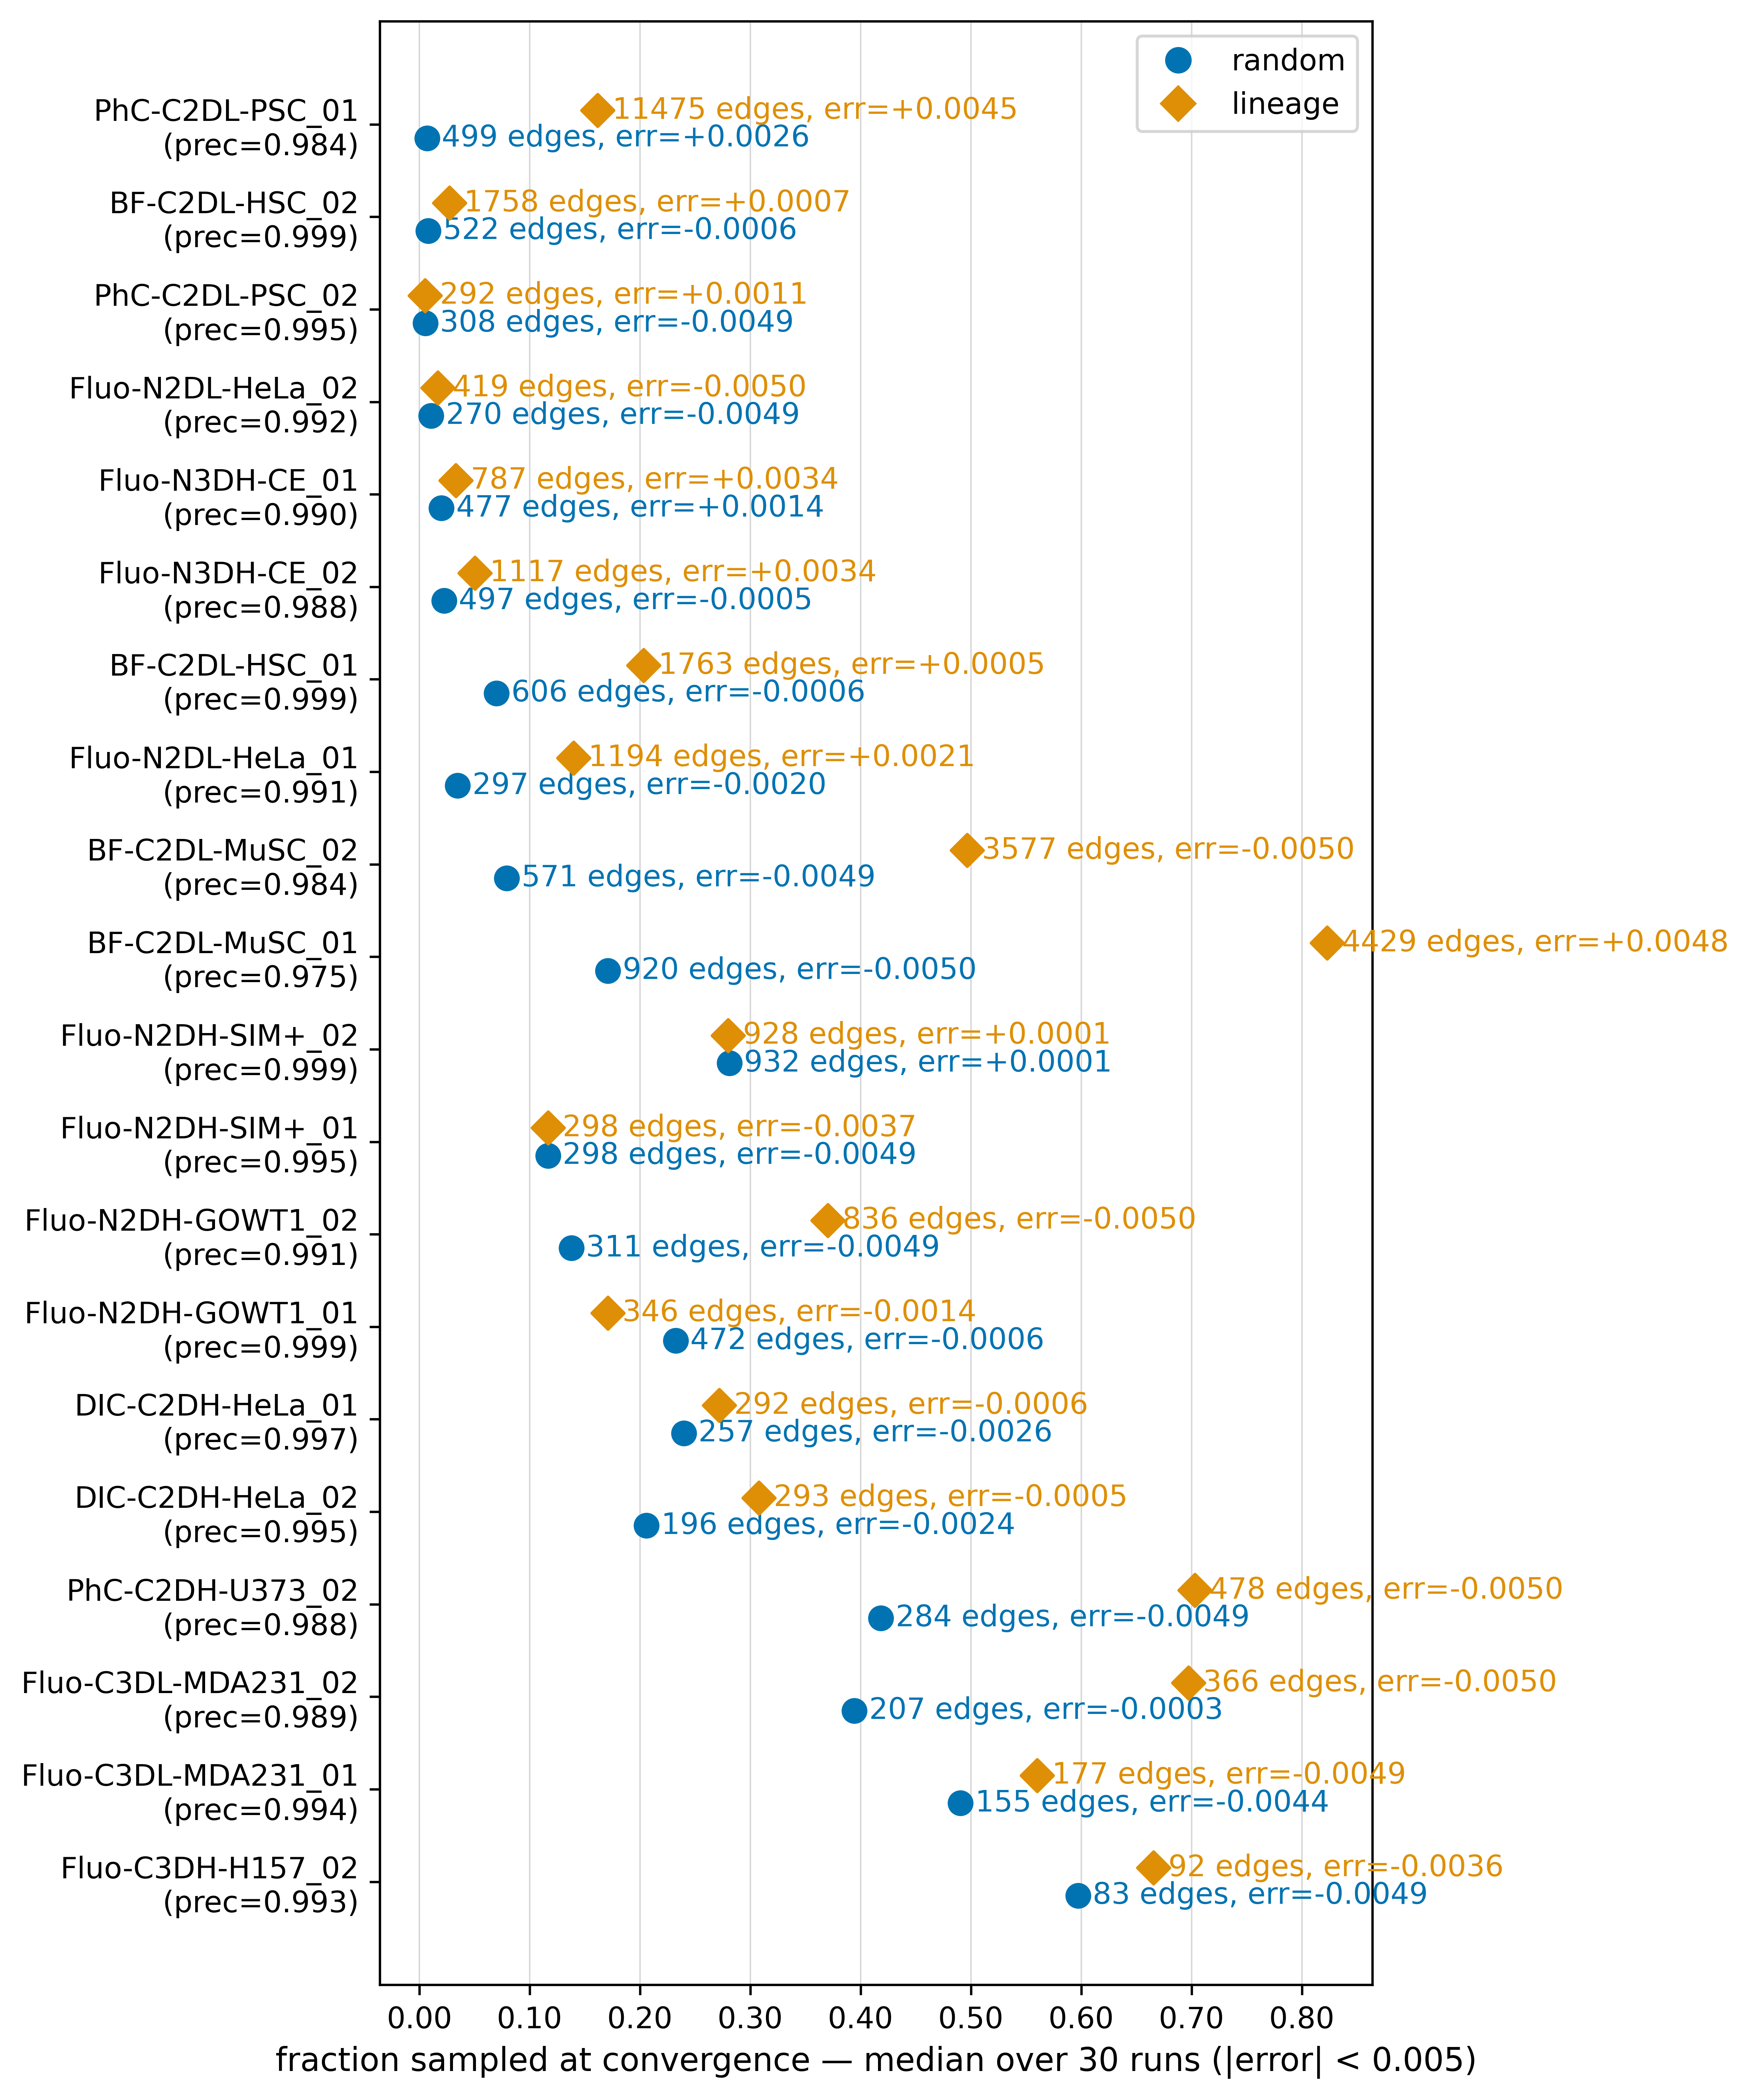

In [9]:
ds_order = col_order[::-1]

markers = {'random': 'o', 'trajectory': 'D'}

fig, ax = plt.subplots(figsize=(8.27, 10), dpi=600)

offsets = {'random': -0.15, 'trajectory': 0.15}
for method, color in colors.items():
    sub = conv[conv['method'] == method].set_index('ds_name').reindex(ds_order)
    for i, ds_name in enumerate(ds_order):
        row = sub.loc[ds_name]
        y = i + offsets[method]
        ax.scatter(row['conv_frac_median'], y, color=color, zorder=3,
                   marker=markers[method], s=60)
        ax.annotate(
            f"{row['conv_n_edges_median']} edges, err={row['error_at_conv_median']:+.4f}",
            xy=(row['conv_frac_median'], y),
            xytext=(5, 0), textcoords='offset points',
            fontsize=10, va='center', color=color,
        )

true_prec_lookup = ds_info.set_index('ds_name')['true_precision']
yticklabels = [f"{ds}\n(prec={true_prec_lookup[ds]:.3f})" for ds in ds_order]
ax.set_yticks(range(len(ds_order)))
ax.set_yticklabels(yticklabels, fontsize=10)
ax.set_xlabel(f'fraction sampled at convergence — median over 30 runs (|error| < {THRESHOLD})', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.tick_params(axis='x', labelsize=10)

legend_handles = [
    plt.Line2D([0], [0], marker=markers[m], color=c, linestyle='none',
               markersize=8, label=m if m == 'random' else 'lineage')
    for m, c in colors.items()
]
ax.legend(handles=legend_handles, fontsize=10)
ax.grid(axis='x', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
summary = (
    conv.groupby('method')['conv_n_edges_median']
    .agg(
        mean_edges='mean',
        ci_lo=lambda x: x.mean() - 1.96 * x.std() / np.sqrt(len(x)),
        ci_hi=lambda x: x.mean() + 1.96 * x.std() / np.sqrt(len(x)),
    )
    .reset_index()
)
summary[['mean_edges', 'ci_lo', 'ci_hi']] = summary[['mean_edges', 'ci_lo', 'ci_hi']].round(0).astype(int)
print(summary.to_latex(index=False, caption='Mean edges to convergence ± 95\% CI across datasets (median per dataset over 30 runs)'))

\begin{table}
\caption{Mean edges to convergence ± 95\% CI across datasets (median per dataset over 30 runs)}
\begin{tabular}{lrrr}
\toprule
method & mean_edges & ci_lo & ci_hi \\
\midrule
random & 408 & 308 & 508 \\
trajectory & 1546 & 407 & 2685 \\
\bottomrule
\end{tabular}
\end{table}



<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:11: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_94619/3007343038.py:11: SyntaxWarning: invalid escape sequence '\%'
  print(summary.to_latex(index=False, caption='Mean edges to convergence ± 95\% CI across datasets (median per dataset over 30 runs)'))


In [23]:
from scipy.stats import hypergeom
from scipy.stats import norm as sp_norm
from statsmodels.stats.multitest import multipletests

stats_sign = stats.merge(ds_info[['ds_name', 'n_edges']], on='ds_name').copy()
stats_sign['n_sampled'] = stats_sign['sample_id'] + 1

N_CHECKPOINTS = 50
OVERESTIMATE_TOL = 1e-6
frac_min = stats_sign['frac_sampled'].min()
frac_max = stats_sign['frac_sampled'].max()
checkpoints = np.linspace(frac_min, frac_max, N_CHECKPOINTS)

def p_overestimate_hyper(N, true_prec, n):
    """P(estimated precision > true precision) under hypergeometric null."""
    K_FP = round(N * (1 - true_prec))
    if K_FP == 0:
        return 0.0  # no FPs in dataset → can never strictly overestimate
    threshold = n * K_FP / N  # overestimate iff k_FP < threshold
    k_max = int(np.ceil(threshold) - 1)
    if k_max < 0:
        return 0.0
    return float(hypergeom.cdf(k_max, N, K_FP, n))

records = []
for frac in checkpoints:
    temp = stats_sign.copy()
    temp['frac_diff'] = (temp['frac_sampled'] - frac).abs()
    closest = temp.loc[temp.groupby(['ds_name', 'method'])['frac_diff'].idxmin()].copy()

    closest['overestimates'] = (closest['mean_prec'] - closest['true_precision']) > OVERESTIMATE_TOL
    closest['p_null'] = closest.apply(
        lambda r: p_overestimate_hyper(r['n_edges'], r['true_precision'], r['n_sampled']),
        axis=1
    )

    for method, grp in closest.groupby('method'):
        obs = grp['overestimates'].sum()
        p_nulls = grp['p_null'].values
        null_mean = p_nulls.sum()
        null_var = (p_nulls * (1 - p_nulls)).sum()
        null_std = np.sqrt(null_var)
        z = (obs - null_mean) / null_std if null_std > 0 else 0.0
        pval = float(sp_norm.sf(z))
        records.append({
            'frac_sampled': frac,
            'method': method,
            'obs_count': int(obs),
            'null_mean': null_mean,
            'pval': pval,
        })

sign_df = pd.DataFrame(records)

# BH correction per method
for method, grp in sign_df.groupby('method'):
    _, bh_pvals, _, _ = multipletests(grp['pval'], method='fdr_bh')
    sign_df.loc[grp.index, 'pval_bh'] = bh_pvals

sign_df['significant'] = sign_df['pval_bh'] < 0.05
sign_df.head()

,frac_sampled,method,obs_count,null_mean,pval,pval_bh,significant
0,0.000014,random,15,19.836557,1.000000,1.000000,False
1,0.000014,trajectory,18,19.836557,0.999998,0.999998,False
2,0.020422,random,12,14.243967,0.890130,0.946947,False
3,0.020422,trajectory,16,14.243967,0.168434,0.271668,False
4,0.040830,random,9,13.075253,0.980246,1.000000,False


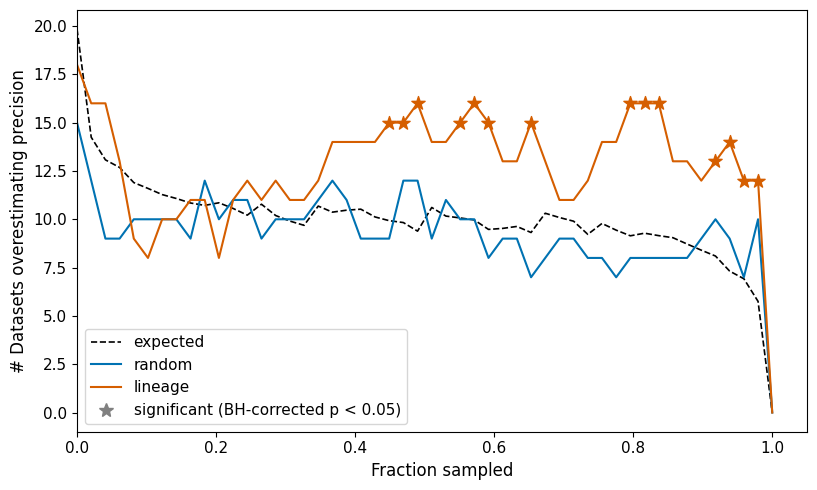

In [26]:
METHOD_COLORS = {'random': '#0072B2', 'trajectory': '#D55E00'}
METHOD_LABELS = {'random': 'random', 'trajectory': 'lineage'}

fig, ax = plt.subplots(figsize=(8.27, 5))

# Null expected count (dataset-property-based, average tiny method differences away)
null_ref = sign_df.groupby('frac_sampled')['null_mean'].mean()
ax.plot(null_ref.index, null_ref.values, color='black', linestyle='--',
        linewidth=1.2, zorder=1)

legend_handles = [
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='expected'),
]

for method, grp in sign_df.groupby('method'):
    color = METHOD_COLORS[method]
    ax.plot(grp['frac_sampled'], grp['obs_count'],
            color=color, label=METHOD_LABELS[method], linewidth=1.5, zorder=2)
    sig = grp[grp['significant']]
    if not sig.empty:
        ax.scatter(sig['frac_sampled'], sig['obs_count'],
                   color=color, marker='*', s=100, zorder=3)
    legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=1.5, label=METHOD_LABELS[method]))

legend_handles.append(
    plt.Line2D([0], [0], marker='*', color='grey', linestyle='none', markersize=10,
               label='significant (BH-corrected p < 0.05)')
)

ax.set_xlabel('Fraction sampled', fontsize=12)
ax.set_ylabel('# Datasets overestimating precision', fontsize=12)
ax.set_xlim(left=0)
ax.tick_params(labelsize=11)
ax.legend(handles=legend_handles, fontsize=11)

fig.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05
N_CHECKPOINTS = 20

true_prec_lookup = ds_info.set_index('ds_name')['true_precision']
n_edges_lookup = ds_info.set_index('ds_name')['n_edges']
conv_edges = conv.set_index(['ds_name', 'method'])['conv_n_edges_median']

test_ds = stats['ds_name'].unique()
traj_df = df[(df['ds_name'].isin(test_ds)) & (df['method'] == 'trajectory')].copy()
traj_df = traj_df.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')

test_records = []
for ds_name, group in traj_df.groupby('ds_name'):
    true_prec = true_prec_lookup[ds_name]
    n_edges = n_edges_lookup[ds_name]

    checkpoint_edges = set(np.linspace(0, n_edges - 1, N_CHECKPOINTS + 1, dtype=int)[1:])
    for m in ['random', 'trajectory']:
        ce = conv_edges.get((ds_name, m))
        if ce is not None and not np.isnan(ce):
            checkpoint_edges.add(int(ce))

    for sample_id in sorted(checkpoint_edges):
        sub = group[group['sample_id'] == sample_id]
        if len(sub) < 2:
            available = group['sample_id'].values
            nearest = available[np.argmin(np.abs(available - sample_id))]
            sub = group[group['sample_id'] == nearest]
            sample_id = int(nearest)
        if len(sub) < 2:
            continue

        estimates = sub['prec_estimate'].values
        errors = estimates - true_prec
        _, t_p = ttest_1samp(estimates, true_prec, alternative='greater')

        ce_rand = conv_edges.get((ds_name, 'random'))
        ce_traj = conv_edges.get((ds_name, 'trajectory'))
        is_random_conv = (not pd.isna(ce_rand)) and int(ce_rand) == sample_id
        is_traj_conv = (not pd.isna(ce_traj)) and int(ce_traj) == sample_id

        test_records.append({
            'ds_name': ds_name,
            'sample_id': sample_id,
            'frac_sampled': round((sample_id + 1) / n_edges, 2),
            'mean_error': errors.mean(),
            't_p': t_p,
            'is_random_conv': is_random_conv,
            'is_traj_conv': is_traj_conv,
        })

test_df = pd.DataFrame(test_records)
test_df['is_conv_point'] = test_df['is_random_conv'] | test_df['is_traj_conv']

# B-H correction per dataset
test_df['t_p_corr'] = float('nan')
for ds_name, grp in test_df.groupby('ds_name'):
    valid = grp['t_p'].notna()
    if valid.sum() > 1:
        _, corrected, _, _ = multipletests(grp.loc[valid.index[valid], 't_p'], method='fdr_bh')
        test_df.loc[valid.index[valid], 't_p_corr'] = corrected
test_df['t_sig'] = test_df['t_p_corr'] < ALPHA

/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


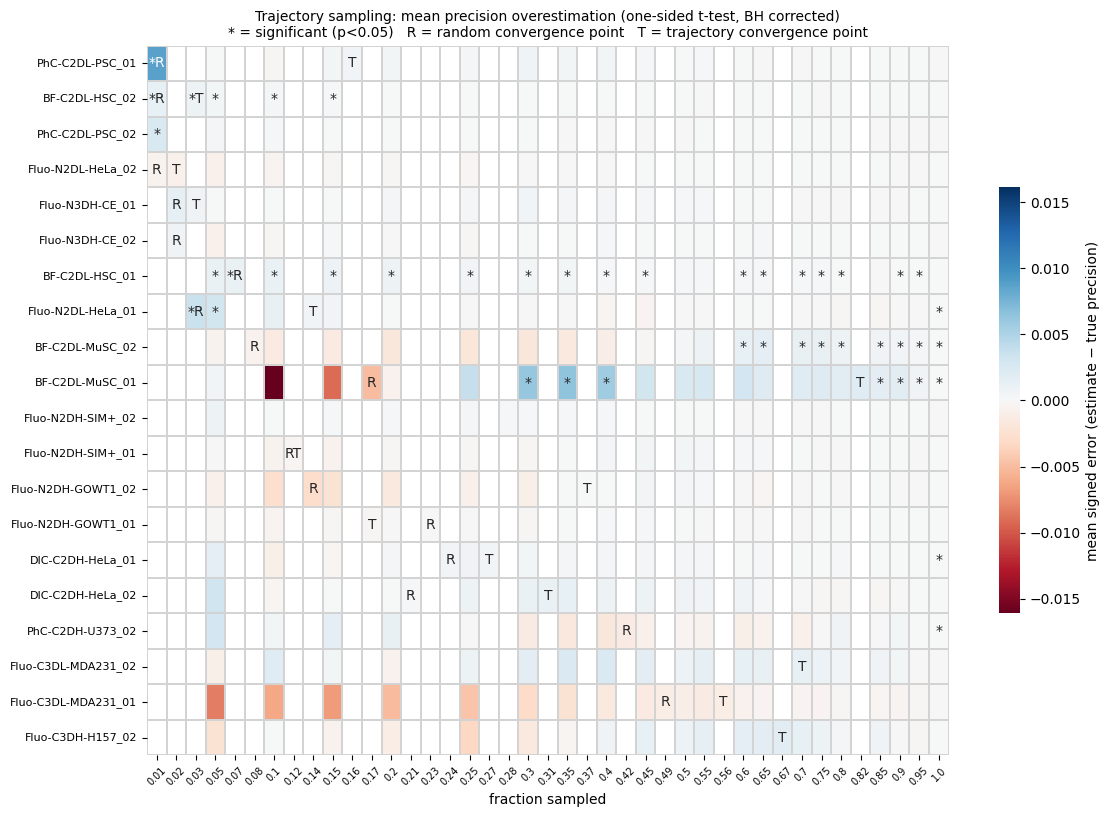

In [46]:
# pivot to heatmap: rows=datasets, cols=frac_sampled checkpoints
error_pivot     = test_df.pivot_table(index='ds_name', columns='frac_sampled', values='mean_error').reindex(col_order)
sig_pivot       = test_df.pivot_table(index='ds_name', columns='frac_sampled', values='t_sig').reindex(col_order)
rand_conv_pivot = test_df.pivot_table(index='ds_name', columns='frac_sampled', values='is_random_conv').reindex(col_order)
traj_conv_pivot = test_df.pivot_table(index='ds_name', columns='frac_sampled', values='is_traj_conv').reindex(col_order)

# build annotation cell by cell to avoid NaN + str issues
annot = pd.DataFrame('', index=error_pivot.index, columns=error_pivot.columns)
for ds in annot.index:
    for frac in annot.columns:
        label = ''
        if sig_pivot.loc[ds, frac] == True:
            label += '*'
        if rand_conv_pivot.loc[ds, frac] == True:
            label += 'R'
        if traj_conv_pivot.loc[ds, frac] == True:
            label += 'T'
        annot.loc[ds, frac] = label

vmax = error_pivot.abs().max().max()

fig, ax = plt.subplots(figsize=(11.69, 8.27))  # A4 landscape
sns.heatmap(
    error_pivot, ax=ax,
    cmap='RdBu', center=0, vmin=-vmax, vmax=vmax,
    annot=annot, fmt='',
    linewidths=0.3, linecolor='lightgrey',
    cbar_kws={'label': 'mean signed error (estimate − true precision)', 'shrink': 0.6},
)
ax.set_xlabel('fraction sampled', fontsize=10)
ax.set_ylabel('')
ax.set_title(
    f'Trajectory sampling: mean precision overestimation (one-sided t-test, BH corrected)\n'
    f'* = significant (p<{ALPHA})   R = random convergence point   T = trajectory convergence point',
    fontsize=10,
)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()